In [1]:
# Import das bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report, ConfusionMatrixDisplay

In [2]:
# Preparação do dataset
df = pd.read_csv('dataset_emprestimo_aprovacao.csv')

In [3]:
# Criação de novas variáveis (feature engeneering)
x = df[['renda_mensal', 'score_credito', 'dividas_ativas']]
y = df['emprestimo_aprovado']

# Separação de treinamento e testes
x_train, x_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.3,
    random_state=42
)

In [4]:
# Treinamento do modelo (Regressão logística)
modelo_credito = LogisticRegression()
modelo_credito.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [5]:
# Previsão do modelo
y_pred = modelo_credito.predict(x_test)

print(f"Acurácia: {accuracy_score(y_test, y_pred):.2f}")
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))

Acurácia: 0.77

Relatório de Classificação:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         7
           1       0.77      1.00      0.87        23

    accuracy                           0.77        30
   macro avg       0.38      0.50      0.43        30
weighted avg       0.59      0.77      0.67        30



C:\Users\Bruno\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Bruno\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Bruno\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capital

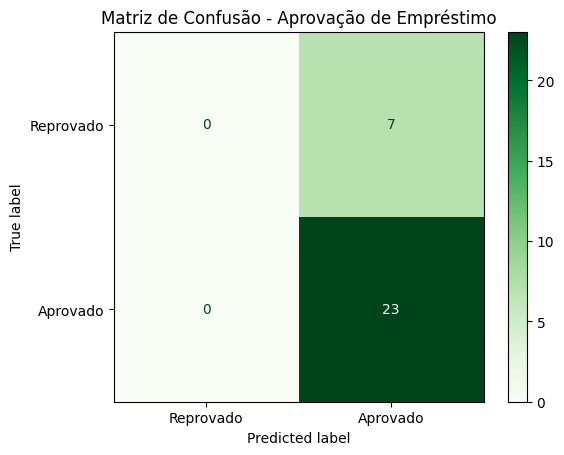

In [6]:
# Matriz de confusão
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    display_labels=["Reprovado", "Aprovado"],
    cmap="Greens"
)
plt.title("Matriz de Confusão - Aprovação de Empréstimo")
plt.savefig('matriz_confusao_emprestimo.png') # Salva a imagem
plt.show()

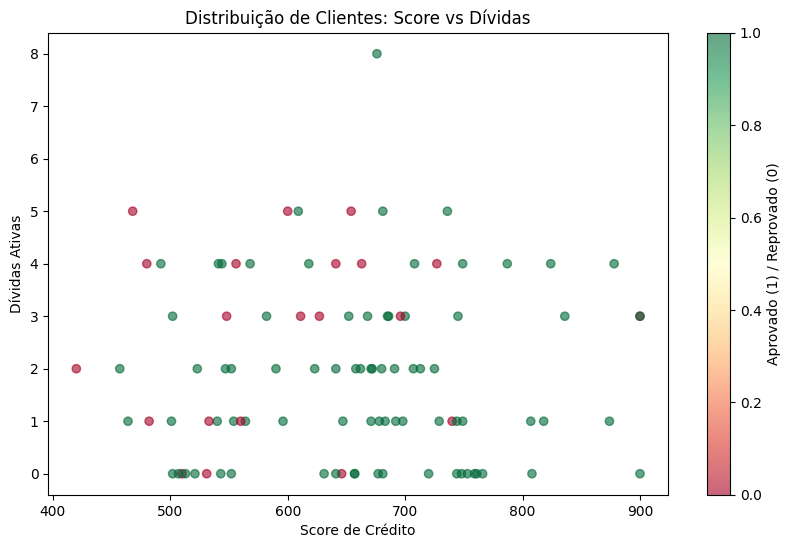

In [7]:
# Visualização dos dados
plt.figure(figsize=(10, 6))
scatter = plt.scatter(df['score_credito'], df['dividas_ativas'], c=df['emprestimo_aprovado'], cmap='RdYlGn', alpha=0.6)
plt.colorbar(scatter, label='Aprovado (1) / Reprovado (0)')
plt.xlabel("Score de Crédito")
plt.ylabel("Dívidas Ativas")
plt.title("Distribuição de Clientes: Score vs Dívidas")
plt.savefig('distribuicao_clientes.png')
plt.show()

In [8]:
# Teste individual de previsão, leva em consideração score e dividas
novo_cliente = pd.DataFrame({
    'renda_mensal': [0],
    'score_credito': [100],
    'dividas_ativas': [0]
})

previsao = modelo_credito.predict(novo_cliente)
probabilidade = modelo_credito.predict_proba(novo_cliente)

resultado = "APROVADO" if previsao[0] == 1 else "REPROVADO"
print(f"Resultado da Previsão: {resultado}")
print(f"Probabilidade de Aprovação: {probabilidade[0][1]:.2%}")

Resultado da Previsão: REPROVADO
Probabilidade de Aprovação: 46.93%
